# VECM Анализ: Золото и золотодобывающие индексы

### Коинтеграция и долгосрочное равновесие между золотом, индексами и макро-факторами

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
import matplotlib.dates as mdates
import numpy as np
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', module='statsmodels')

---
## 1. Загрузка данных

### Все доступные индексы (золотодобывающие и макро)

In [4]:
# ============================================
# НАСТРОЙКА: Выбор папки с данными
# ============================================
DATA_FOLDER = "data2/"
GOLD_FILE = "data2/Прошлые данные - XAU_USD.csv"
print(f"📁 Используемая папка: {DATA_FOLDER}")
print(f"📁 Файл золота: {GOLD_FILE}")

📁 Используемая папка: data2/
📁 Файл золота: data2/Прошлые данные - XAU_USD.csv


In [5]:
# ============================================
# КОНФИГУРАЦИЯ ВСЕХ ДОСТУПНЫХ ФАЙЛОВ
# ============================================

# Золото (отдельно, через data1)
files_config = [
    # --- Золотодобывающие индексы ---
    {"path": "Прошлые данные - Arca Gold Miners.csv", "col_name": "GDM"},
    {"path": "Прошлые данные - Arca Gold BUGS.csv", "col_name": "HUI"},
    {"path": "Прошлые данные - FTSE Gold Mines.csv", "col_name": "FTGM"},
    {"path": "Прошлые данные - Philadelphia Gold_Silver.csv", "col_name": "XAU"},
    {"path": "Прошлые данные по XGD.csv", "col_name": "XGD"},
    {"path": "Прошлые данные по GDX.csv", "col_name": "GDX"},
    {"path": "Прошлые данные по GDXJ.csv", "col_name": "GDXJ"},
    {"path": "Прошлые данные по SGDM.csv", "col_name": "SGDM"},
    {"path": "Прошлые данные - NYSE Arca Gold Miners GTR.csv", "col_name": "GDM_GTR"},
    {"path": "Прошлые данные - MVIS Global Junior Gold Miners TR Net.csv", "col_name": "MVG"},
    {"path": "Прошлые данные - MSCI ACWI IMI.csv", "col_name": "MSCI"},
    
    # --- Макро-факторы ---
    {"path": "Прошлые данные - S&P 500.csv", "col_name": "SP500"},
    {"path": "Прошлые данные - Индекс USD.csv", "col_name": "USD"},
    {"path": "Прошлые данные - Фьючерс на нефть Brent.csv", "col_name": "Oil"},
    {"path": "Прошлые данные - CBOE Volatility Index.csv", "col_name": "Vix"},
    {"path": "Прошлые данные - Фьючерс на нефть Brent (1).csv", "col_name": "Oil2"},
    {"path": "Прошлые данные - Arca Gold BUGS (1).csv", "col_name": "HUI2"},
    {"path": "Прошлые данные - Arca Gold Miners (1).csv", "col_name": "GDM2"},
]

In [6]:
# ============================================
# ЗАГРУЗКА ЗОЛОТА (data1)
# ============================================
data1 = pd.read_csv(GOLD_FILE)
if 'Дата' in data1.columns:
    data1 = data1.rename(columns={'Дата': 'Date'})
data1['Date'] = pd.to_datetime(data1['Date'], format='%d.%m.%Y')
if 'Цена' in data1.columns:
    data1 = data1.rename(columns={'Цена': 'Gold'})
elif 'Price' in data1.columns:
    data1 = data1.rename(columns={'Price': 'Gold'})
data1 = data1[['Date', 'Gold']]
if data1['Gold'].dtype == 'object':
    data1['Gold'] = data1['Gold'].astype(str).str.replace('.', '').str.replace(',', '.')
    data1['Gold'] = pd.to_numeric(data1['Gold'], errors='coerce')
data1 = data1.sort_values('Date').reset_index(drop=True)
print(f"✅ Золото загружено: {len(data1)} записей ({data1['Date'].min()} - {data1['Date'].max()})")

✅ Золото загружено: 4902 записей (2007-02-19 00:00:00 - 2025-12-16 00:00:00)


In [7]:
# ============================================
# ФУНКЦИИ ЗАГРУЗКИ
# ============================================
def clean_numeric(series):
    """Преобразует строковые числа в float"""
    if series.dtype == 'object':
        cleaned = series.copy().astype(str)
        cleaned = cleaned.str.replace('−', '-', regex=False)
        cleaned = cleaned.str.replace('.', '').str.replace(',', '.')
        return pd.to_numeric(cleaned, errors='coerce')
    return series

def load_index_file(config, folder):
    """Загрузка одного файла индекса"""
    try:
        file_path = folder + config["path"]
        df = pd.read_csv(file_path)
        
        if 'Date' not in df.columns and 'Дата' in df.columns:
            df = df.rename(columns={'Дата': 'Date'})
        
        df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y', errors='coerce')
        df = df.dropna(subset=['Date'])
        
        if 'Price' in df.columns:
            df = df.rename(columns={'Price': config['col_name']})
        elif 'Цена' in df.columns:
            df = df.rename(columns={'Цена': config['col_name']})
        
        if config['col_name'] in df.columns:
            df[config['col_name']] = clean_numeric(df[config['col_name']])
            df = df[['Date', config['col_name']]].dropna()
            df = df.drop_duplicates(subset=['Date'], keep='first')
            df = df.sort_values('Date').reset_index(drop=True)
            return df
        else:
            print(f"  ⚠️ Столбец не найден в {config['path']}: {df.columns.tolist()}")
            return None
    except Exception as e:
        print(f"  ⚠️ Ошибка загрузки {config['col_name']}: {e}")
        return None

In [8]:
# ============================================
# ЗАГРУЗКА ВСЕХ ИНДЕКСОВ
# ============================================
print("="*80)
print("📊 ЗАГРУЗКА ВСЕХ ДОСТУПНЫХ ДАННЫХ")
print("="*80)

# Загружаем файлы из data2/
all_dfs = {'Gold': data1}
loaded = []
for config in files_config:
    df = load_index_file(config, "data2/")
    if df is not None:
        name = config['col_name']
        all_dfs[name] = df
        loaded.append(name)
        print(f"✅ {name:8}: {len(df)} записей")

print(f"\n✅ Всего загружено: {len(loaded)} индексов/факторов")
print(f"   {loaded}")

📊 ЗАГРУЗКА ВСЕХ ДОСТУПНЫХ ДАННЫХ
✅ GDM     : 4759 записей
✅ HUI     : 3914 записей
✅ FTGM    : 4919 записей
✅ XAU     : 4741 записей
✅ XGD     : 4727 записей
✅ GDX     : 4768 записей
✅ GDXJ    : 4125 записей
✅ SGDM    : 2952 записей
✅ GDM_GTR : 3257 записей
✅ MVG     : 3156 записей
✅ MSCI    : 3519 записей
✅ SP500   : 4738 записей
✅ USD     : 4895 записей
✅ Oil     : 4863 записей
✅ Vix     : 4777 записей
  ⚠️ Ошибка загрузки Oil2: [Errno 2] No such file or directory: 'data2/Прошлые данные - Фьючерс на нефть Brent (1).csv'
  ⚠️ Ошибка загрузки HUI2: [Errno 2] No such file or directory: 'data2/Прошлые данные - Arca Gold BUGS (1).csv'
  ⚠️ Ошибка загрузки GDM2: [Errno 2] No such file or directory: 'data2/Прошлые данные - Arca Gold Miners (1).csv'

✅ Всего загружено: 15 индексов/факторов
   ['GDM', 'HUI', 'FTGM', 'XAU', 'XGD', 'GDX', 'GDXJ', 'SGDM', 'GDM_GTR', 'MVG', 'MSCI', 'SP500', 'USD', 'Oil', 'Vix']


In [9]:
# ============================================
# ОБЪЕДИНЕНИЕ ВСЕХ ДАННЫХ В ОДИН DF
# ============================================
print("="*80)
print("📊 ОБЪЕДИНЕНИЕ ДАННЫХ")
print("="*80)

final_df = data1[['Date', 'Gold']].copy()

for name, df in all_dfs.items():
    if name == 'Gold':
        continue
    temp = df[['Date', name]].copy()
    final_df = pd.merge(final_df, temp, on='Date', how='outer')

final_df = final_df.sort_values('Date').reset_index(drop=True)

# Приводим все колонки к числовому типу
for col in final_df.columns:
    if col != 'Date':
        final_df[col] = clean_numeric(final_df[col])

# XGD в CAD → конвертируем в USD через ex_rate
if 'Прошлые данные - CAD_USD.csv' in [f['path'] for f in files_config]:
    pass  # обработано ниже
else:
    try:
        ex_rate = pd.read_csv("data2/Прошлые данные - CAD_USD.csv")
        if 'Дата' in ex_rate.columns:
            ex_rate = ex_rate.rename(columns={'Дата': 'Date'})
        ex_rate['Date'] = pd.to_datetime(ex_rate['Date'], format='%d.%m.%Y')
        if 'Цена' in ex_rate.columns:
            ex_rate = ex_rate.rename(columns={'Цена': 'ex_rate'})
        ex_rate = ex_rate[['Date', 'ex_rate']].dropna()
        ex_rate['ex_rate'] = clean_numeric(ex_rate['ex_rate'])
        
        final_df = pd.merge(final_df, ex_rate, on='Date', how='left')
        final_df['ex_rate'] = final_df['ex_rate'].ffill()
        
        # XGD конвертируем в USD
        if 'XGD' in final_df.columns:
            final_df['XGD'] = final_df['XGD'] * final_df['ex_rate']
            print("✅ XGD сконвертирован из CAD в USD")
        
        # Удаляем ex_rate из финального датасета
        final_df = final_df.drop(columns=['ex_rate'], errors='ignore')
    except Exception as e:
        print(f"⚠️ Ошибка загрузки ex_rate: {e}")

print(f"\n📊 Финальный датасет: {final_df.shape}")
print(f"   Колонки: {list(final_df.columns)}")

📊 ОБЪЕДИНЕНИЕ ДАННЫХ
✅ XGD сконвертирован из CAD в USD

📊 Финальный датасет: (5219, 17)
   Колонки: ['Date', 'Gold', 'GDM', 'HUI', 'FTGM', 'XAU', 'XGD', 'GDX', 'GDXJ', 'SGDM', 'GDM_GTR', 'MVG', 'MSCI', 'SP500', 'USD', 'Oil', 'Vix']


In [10]:
# ============================================
# ИНФОРМАЦИЯ О ПОКРЫТИИ ДАННЫХ
# ============================================
print("="*80)
print("📊 ПОКРЫТИЕ ДАННЫХ ПО ИНДЕКСАМ")
print("="*80)

for col in final_df.columns:
    if col != 'Date':
        first_date = final_df[final_df[col].notnull()]['Date'].min()
        last_date = final_df[final_df[col].notnull()]['Date'].max()
        count = final_df[col].notnull().sum()
        print(f"{col:10}: {first_date.year}-{last_date.year} ({count:6d} записей)")

final_df['Year'] = final_df['Date'].dt.year
yearly_counts = final_df.groupby('Year').count()
print("\n📊 Количество записей по годам:")
print(yearly_counts.iloc[:, 1:].sum(axis=1).to_string())

📊 ПОКРЫТИЕ ДАННЫХ ПО ИНДЕКСАМ
Gold      : 2007-2025 (  4902 записей)
GDM       : 2007-2025 (  4759 записей)
HUI       : 2010-2025 (  3914 записей)
FTGM      : 2007-2025 (  4919 записей)
XAU       : 2007-2025 (  4741 записей)
XGD       : 2007-2025 (  4726 записей)
GDX       : 2007-2025 (  4768 записей)
GDXJ      : 2009-2026 (  4125 записей)
SGDM      : 2014-2026 (  2952 записей)
GDM_GTR   : 2013-2026 (  3257 записей)
MVG       : 2014-2025 (  3156 записей)
MSCI      : 2012-2025 (  3519 записей)
SP500     : 2007-2025 (  4738 записей)
USD       : 2007-2025 (  4895 записей)
Oil       : 2007-2025 (  4863 записей)
Vix       : 2007-2025 (  4777 записей)

📊 Количество записей по годам:
Year
2007    2208
2008    2557
2009    2585
2010    2962
2011    3050
2012    3161
2013    3386
2014    3863
2015    4079
2016    4119
2017    4138
2018    4143
2019    4118
2020    4173
2021    4111
2022    4085
2023    4095
2024    4123
2025    3942
2026     113


---
## 2. Выбор датасета и синхронизация

### Выберите датасет для анализа:

In [11]:
# ============================================
# ВЫБОР ДАТАСЕТА
# ============================================
# Измените эту переменную для выбора периода:
# - dataset_2004: все данные с 2004 года
# - dataset_2008: данные с 2008 года
# - dataset_2012: данные с 2012 года
# - dataset_2014: данные с 2014 года

columns = ['Gold', 'GDM', 'FTGM', 'XAU', 'XGD', 'GDX', 'SP500', 'USD', 'Oil', 'Vix']

SELECTED_DATASET = "dataset_2007"  # ← ИЗМЕНИТЕ ЗДЕСЬ ДЛЯ ВЫБОРА

print(f"📊 ВЫБРАН ДАТАСЕТ: {SELECTED_DATASET}")

📊 ВЫБРАН ДАТАСЕТ: dataset_2007


In [12]:
# ============================================
# СОЗДАНИЕ ДАТАСЕТОВ (БЕЗ синхронизации по календарю)
# ============================================
df = final_df.copy()
df = df.set_index('Date').sort_index()
df = df[columns]

# Forward-fill для макро-переменных (Vix, Oil и т.д.)
# ВАЖНО: Не синхронизируем по календарю ни одного индекса!
# Это сохраняет максимальный временной диапазон данных.
# VECM сам сделает dropna() внутри себя при оценке.
macro_candidates = ['Vix', 'Oil', 'Oil2', 'OilWTI', 'SP500', 'USD']
macro_to_fill = [c for c in macro_candidates if c in df.columns]
df[macro_to_fill] = df[macro_to_fill].ffill()

# Создаем разные версии датасета (просто фильтр по дате, ничего не обрезаем)
dataset_2004 = df.copy()
dataset_2007 = df[df.index >= '2007-01-01'].copy()
dataset_2012 = df[df.index >= '2012-01-01'].copy()
dataset_2014 = df[df.index >= '2014-01-01'].copy()

# Выбираем по SELECTED_DATASET
dataset = {
    "dataset_2004": dataset_2004,
    "dataset_2007": dataset_2007,
    "dataset_2012": dataset_2012,
    "dataset_2014": dataset_2014
}[SELECTED_DATASET]

print(f"📊 Размерность выбранного датасета: {dataset.shape}")
print(f"   Период: {dataset.index.min()} - {dataset.index.max()}")
print(f"   Колонки: {list(dataset.columns)}")

# Проверка пропусков
print("\n📊 Пропуски:")
print(dataset.isna().sum()[dataset.isna().sum() > 0].to_string())

📊 Размерность выбранного датасета: (5219, 10)
   Период: 2007-02-16 00:00:00 - 2026-02-25 00:00:00
   Колонки: ['Gold', 'GDM', 'FTGM', 'XAU', 'XGD', 'GDX', 'SP500', 'USD', 'Oil', 'Vix']

📊 Пропуски:
Gold     317
GDM      460
FTGM     300
XAU      478
XGD      493
GDX      451
SP500      2
USD        2
Oil        1
Vix        2


In [13]:
# ============================================
# РАСЧЕТ ДОХОДНОСТЕЙ (log-returns) ПО КАЖДОЙ ПЕРЕМЕННОЙ ОТДЕЛЬНО
# ============================================
dataset_returns = dataset.copy()
for col in dataset_returns.columns:
    if col != 'Date':
        dataset_returns[col] = np.log(dataset[col]).diff()

dataset_returns = dataset_returns.dropna()  # удаляем первую строку (NaN от diff)
print(f"📊 Размерность после расчета доходностей: {dataset_returns.shape}")
print(f"   Период: {dataset_returns.index.min()} - {dataset_returns.index.max()}")

# ВАЖНО: Показываем реальное покрытие КАЖДОЙ переменной
print("\n📊 Доступность каждой переменной (сколько наблюдений):")
for col in dataset_returns.columns:
    count = dataset_returns[col].notna().sum()
    first = dataset_returns[col].first_valid_index()
    last = dataset_returns[col].last_valid_index()
    if count > 0:
        print(f"   {col:10}: {count:5d} записей  ({first} - {last})")
    else:
        print(f"   {col:10}: 0 записей (НЕТ ДАННЫХ)")

print(f"\n⚠️ Пояснение: размер {dataset_returns.shape[0]} — это количество строк,")
print(f"   где ЕСТЬ ДАННЫЕ ПО ВСЕМ 17 колонкам сразу.")
print(f"   Если Gold есть с 2007, но GDX только с 2014 —")
print(f"   то dropna() обрежет данные до 2014.")
print(f"   Для работы с бОльшим периодом — исключите индексы с малым покрытием.")

📊 Размерность после расчета доходностей: (4177, 10)
   Период: 2007-02-21 00:00:00 - 2025-12-12 00:00:00

📊 Доступность каждой переменной (сколько наблюдений):
   Gold      :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)
   GDM       :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)
   FTGM      :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)
   XAU       :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)
   XGD       :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)
   GDX       :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)
   SP500     :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)
   USD       :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)
   Oil       :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)
   Vix       :  4177 записей  (2007-02-21 00:00:00 - 2025-12-12 00:00:00)

⚠️ Пояснение: размер 4177 — это количество строк,
   где ЕСТЬ ДАННЫЕ ПО ВСЕМ 17 колонкам сразу.
   

---
## 3. Тесты стационарности

In [14]:
from statsmodels.tsa.stattools import adfuller, kpss

def check_stationarity(timeseries, alpha=0.05):
    """ADF тест"""
    result = adfuller(timeseries.dropna())
    p_value = result[1]
    return p_value, p_value < alpha

print("="*80)
print("📊 ТЕСТЫ НА СТАЦИОНАРНОСТЬ (ADF)")
print("="*80)

print("\n--- УРОВНИ ЦЕН ---")
for col in dataset.columns:
    if col == 'Date':
        continue
    p_val, stationarity = check_stationarity(dataset[col])
    print(f"{col:10}: p-value = {p_val:.4f} → {'СТАЦИОНАРЕН' if stationarity else 'НЕСТАЦИОНАРЕН (I(1))'}")

print("\n--- ДОХОДНОСТИ (log-returns) ---")
for col in dataset_returns.columns:
    if col == 'Date':
        continue
    p_val, stationarity = check_stationarity(dataset_returns[col])
    print(f"{col:10}: p-value = {p_val:.4f} → {'СТАЦИОНАРЕН' if stationarity else 'НЕСТАЦИОНАРЕН'}")

📊 ТЕСТЫ НА СТАЦИОНАРНОСТЬ (ADF)

--- УРОВНИ ЦЕН ---
Gold      : p-value = 1.0000 → НЕСТАЦИОНАРЕН (I(1))
GDM       : p-value = 0.8738 → НЕСТАЦИОНАРЕН (I(1))
FTGM      : p-value = 0.9148 → НЕСТАЦИОНАРЕН (I(1))
XAU       : p-value = 0.9301 → НЕСТАЦИОНАРЕН (I(1))
XGD       : p-value = 0.9504 → НЕСТАЦИОНАРЕН (I(1))
GDX       : p-value = 0.8250 → НЕСТАЦИОНАРЕН (I(1))
SP500     : p-value = 0.9987 → НЕСТАЦИОНАРЕН (I(1))
USD       : p-value = 0.5346 → НЕСТАЦИОНАРЕН (I(1))
Oil       : p-value = 0.1926 → НЕСТАЦИОНАРЕН (I(1))
Vix       : p-value = 0.0000 → СТАЦИОНАРЕН

--- ДОХОДНОСТИ (log-returns) ---
Gold      : p-value = 0.0000 → СТАЦИОНАРЕН
GDM       : p-value = 0.0000 → СТАЦИОНАРЕН
FTGM      : p-value = 0.0000 → СТАЦИОНАРЕН
XAU       : p-value = 0.0000 → СТАЦИОНАРЕН
XGD       : p-value = 0.0000 → СТАЦИОНАРЕН
GDX       : p-value = 0.0000 → СТАЦИОНАРЕН
SP500     : p-value = 0.0000 → СТАЦИОНАРЕН
USD       : p-value = 0.0000 → СТАЦИОНАРЕН
Oil       : p-value = 0.0000 → СТАЦИОНАРЕН
Vix       : p-va

---
## 4. Тест Йохансена на коинтеграцию

In [15]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_coint_rank

# Определяем базовые переменные и индексы
base_vars = ['Gold', 'SP500', 'USD', 'Oil', 'Vix']
base_vars = [v for v in base_vars if v in dataset.columns]

indices_list = ['GDM', 'HUI', 'FTGM', 'XAU', 'XGD', 'GDX', 'GDXJ', 'SGDM', 'MVG', 'MSCI']
indices_list = [v for v in indices_list if v in dataset.columns]

print(f"📊 Базовые переменные: {base_vars}")
print(f"📊 Индексы: {indices_list}")

for idx in indices_list:
    vars_to_use = [idx] + base_vars
    data_subset = dataset[vars_to_use].dropna()
    
    if len(data_subset) < 100:
        print(f"\n⚠️ {idx}: недостаточно данных ({len(data_subset)})")
        continue
    
    try:
        jres = coint_johansen(data_subset, det_order=0, k_ar_diff=2)
        print(f"\n{'='*60}")
        print(f"📊 Тест Йохансена: {idx} + {base_vars}")
        print(f"{'='*60}")
        print("Trace statistics:", [round(v, 2) for v in jres.lr1])
        print("CV (95%):       ", [round(v, 2) for v in jres.cvt[:, 1]])
        
        # Определяем ранг
        rank = 0
        for i in range(len(jres.lr1)):
            if jres.lr1[i] > jres.cvt[i, 1]:
                rank = i + 1
        print(f"Ранг коинтеграции: r = {rank}")
    except Exception as e:
        print(f"\n⚠️ {idx}: ошибка теста - {e}")

📊 Базовые переменные: ['Gold', 'SP500', 'USD', 'Oil', 'Vix']
📊 Индексы: ['GDM', 'FTGM', 'XAU', 'XGD', 'GDX']

📊 Тест Йохансена: GDM + ['Gold', 'SP500', 'USD', 'Oil', 'Vix']
Trace statistics: [195.67, 90.19, 54.36, 31.41, 15.71, 3.26]
CV (95%):        [95.75, 69.82, 47.85, 29.8, 15.49, 3.84]
Ранг коинтеграции: r = 5

📊 Тест Йохансена: FTGM + ['Gold', 'SP500', 'USD', 'Oil', 'Vix']
Trace statistics: [199.73, 90.16, 53.78, 31.26, 16.08, 3.74]
CV (95%):        [95.75, 69.82, 47.85, 29.8, 15.49, 3.84]
Ранг коинтеграции: r = 5

📊 Тест Йохансена: XAU + ['Gold', 'SP500', 'USD', 'Oil', 'Vix']
Trace statistics: [194.18, 89.45, 53.81, 31.63, 15.13, 2.75]
CV (95%):        [95.75, 69.82, 47.85, 29.8, 15.49, 3.84]
Ранг коинтеграции: r = 4

📊 Тест Йохансена: XGD + ['Gold', 'SP500', 'USD', 'Oil', 'Vix']
Trace statistics: [195.79, 89.31, 54.35, 30.23, 15.63, 3.53]
CV (95%):        [95.75, 69.82, 47.85, 29.8, 15.49, 3.84]
Ранг коинтеграции: r = 5

📊 Тест Йохансена: GDX + ['Gold', 'SP500', 'USD', 'Oil', '

---
## 5. VECM Модели

In [16]:
from statsmodels.tsa.vector_ar.vecm import VECM, select_order
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy import stats

def build_vecm_model_safe(data, period_name="", max_lags=4, deterministic="ci"):
    """
    Безопасное построение VECM модели
    """
    print(f"\n{'='*80}")
    print(f"📊 VECM: {period_name}")
    print(f"{'='*80}")
    
    result_dict = {'success': False, 'model': None}
    
    # 1. Информация о данных
    print(f"   Размер: {data.shape}")
    print(f"   Переменные: {list(data.columns)}")
    print(f"   Наблюдений: {len(data)}")
    
    result_dict['data_info'] = {
        'shape': data.shape,
        'columns': list(data.columns),
        'n_obs': len(data)
    }
    
    # 2. Выбор лагов
    print("\n📊 Выбор оптимальных лагов:")
    try:
        lag_order = select_order(data, maxlags=max_lags)
        optimal_lag = lag_order.aic
        print(f"   AIC: {optimal_lag}, BIC: {lag_order.bic}, HQIC: {lag_order.hqic}")
    except:
        optimal_lag = 2
        print(f"   Используем по умолчанию: {optimal_lag}")
    
    result_dict['optimal_lag'] = optimal_lag
    
    # 3. Тест Йохансена
    print("\n📊 Тест Йохансена:")
    try:
        jres = coint_johansen(data, det_order=0, k_ar_diff=optimal_lag)
        coint_rank = 0
        for i in range(len(jres.lr1)):
            if jres.lr1[i] > jres.cvt[i, 1]:
                coint_rank = i + 1
        print(f"   Ранг коинтеграции: {coint_rank}")
    except:
        coint_rank = 1
        print(f"   Ошибка теста, используем ранг: {coint_rank}")
    
    result_dict['coint_rank'] = coint_rank
    
    # 4. Оценка VECM
    print(f"\n📊 Оценка VECM (лаги={optimal_lag}, ранг={coint_rank}):")
    for k, r in [(optimal_lag, coint_rank), (min(optimal_lag, 3), max(coint_rank, 1)), (2, 1)]:
        try:
            model = VECM(data, k_ar_diff=k, coint_rank=r, deterministic=deterministic)
            vecm_result = model.fit()
            result_dict['model'] = vecm_result
            result_dict['success'] = True
            print(f"   ✅ Модель успешно оценена (k={k}, r={r})")
            break
        except Exception as e:
            print(f"   ⚠️ Ошибка (k={k}, r={r}): {str(e)[:60]}")
    
    if not result_dict['success']:
        print("   ❌ Не удалось оценить VECM")
        return result_dict
    
    # 5. Коинтеграционные вектора
    if hasattr(vecm_result, 'beta') and vecm_result.beta is not None:
        beta_df = pd.DataFrame(
            vecm_result.beta,
            index=data.columns,
            columns=[f'Вектор {i+1}' for i in range(vecm_result.beta.shape[1])]
        )
        print(f"\n📊 Коинтеграционные вектора (β):")
        print(beta_df.round(4).to_string())
        result_dict['beta'] = beta_df
        result_dict['has_cointegration'] = True
    
    # 6. Скорости коррекции
    if hasattr(vecm_result, 'alpha') and vecm_result.alpha is not None:
        alpha_df = pd.DataFrame(
            vecm_result.alpha,
            index=data.columns,
            columns=[f'Вектор {i+1}' for i in range(vecm_result.alpha.shape[1])]
        )
        print(f"\n📊 Скорости коррекции (α):")
        print(alpha_df.round(6).to_string())
        result_dict['alpha'] = alpha_df
    
    # 7. Диагностика остатков
    if hasattr(vecm_result, 'resid'):
        print(f"\n📊 Диагностика остатков:")
        for i, col in enumerate(data.columns):
            try:
                lb = acorr_ljungbox(vecm_result.resid[:, i], lags=[4], return_df=True)
                pval = lb['lb_pvalue'].iloc[0]
                print(f"   {col:10}: Ljung-Box p={pval:.4f} {'✅' if pval > 0.05 else '⚠️'}")
            except:
                pass
    from statsmodels.stats.diagnostic import het_arch

    # resid — матрица остатков VECM (n_obs x n_vars)
    for i, col in enumerate(data.columns):
        test_result = het_arch(vecm_result.resid[:, i], maxlag=4)
        print(f"{col}: ARCH LM p-value = {test_result[1]:.4f}")
        
    print(f"\n✅ VECM для {period_name} завершена")
    return result_dict

In [17]:
# ============================================
# ЗАПУСК VECM ДЛЯ ВСЕХ ИНДЕКСОВ
# ============================================
base_vars = ['Gold', 'SP500', 'Vix', 'Oil', 'USD']
base_vars = [v for v in base_vars if v in dataset.columns]

indices_list = ['GDM', 'HUI', 'FTGM', 'XAU', 'XGD', 'GDX', 'GDXJ', 'SGDM', 'MVG', 'MSCI']
indices_list = [v for v in indices_list if v in dataset.columns]

print("="*80)
print(f"🚀 ЗАПУСК VECM АНАЛИЗА: {SELECTED_DATASET}")
print(f"   Базовые: {base_vars}")
print(f"   Индексы: {indices_list}")
print("="*80)

all_results = []
for idx in indices_list:
    vars_to_use = [idx] + base_vars
    data_subset = dataset[vars_to_use].dropna()
    
    if len(data_subset) < 100:
        print(f"\n⚠️ {idx}: недостаточно данных ({len(data_subset)}), пропускаем")
        continue
    
    result = build_vecm_model_safe(data_subset, period_name=idx)
    if result['success']:
        all_results.append(result)

🚀 ЗАПУСК VECM АНАЛИЗА: dataset_2007
   Базовые: ['Gold', 'SP500', 'Vix', 'Oil', 'USD']
   Индексы: ['GDM', 'FTGM', 'XAU', 'XGD', 'GDX']

📊 VECM: GDM
   Размер: (4759, 6)
   Переменные: ['GDM', 'Gold', 'SP500', 'Vix', 'Oil', 'USD']
   Наблюдений: 4759

📊 Выбор оптимальных лагов:
   AIC: 4, BIC: 0, HQIC: 1

📊 Тест Йохансена:
   Ранг коинтеграции: 3

📊 Оценка VECM (лаги=4, ранг=3):
   ✅ Модель успешно оценена (k=4, r=3)

📊 Коинтеграционные вектора (β):
       Вектор 1  Вектор 2  Вектор 3
GDM      1.0000   -0.0000    0.0000
Gold    -0.0000    1.0000   -0.0000
SP500    0.0000   -0.0000    1.0000
Vix     23.0238   54.8719 -138.0264
Oil      3.4780    1.0925  -34.9375
USD     34.2754    6.9674 -151.8785

📊 Скорости коррекции (α):
       Вектор 1  Вектор 2  Вектор 3
GDM   -0.002718  0.002405 -0.000010
Gold   0.002014  0.000335  0.000457
SP500 -0.003967  0.004119  0.000448
Vix    0.000352 -0.000307  0.000097
Oil    0.000203 -0.000140  0.000040
USD   -0.000067  0.000039  0.000003

📊 Диагностика 

In [18]:
from sklearn.preprocessing import StandardScaler


all_results = []
for idx in indices_list:
    vars_to_use = base_vars + [idx]
    data_subset = dataset[vars_to_use].dropna()
    scaler = StandardScaler()
    data_scaled = pd.DataFrame(
        scaler.fit_transform(data_subset),
        index=data_subset.index,
        columns=data_subset.columns
    )
    
    if len(data_scaled) < 100:
        print(f"\n⚠️ {idx}: недостаточно данных ({len(data_scaled)}), пропускаем")
        continue
    
    result = build_vecm_model_safe(data_scaled, period_name=idx)
    if result['success']:
        all_results.append(result)


📊 VECM: GDM
   Размер: (4759, 6)
   Переменные: ['Gold', 'SP500', 'Vix', 'Oil', 'USD', 'GDM']
   Наблюдений: 4759

📊 Выбор оптимальных лагов:
   AIC: 4, BIC: 0, HQIC: 1

📊 Тест Йохансена:
   Ранг коинтеграции: 3

📊 Оценка VECM (лаги=4, ранг=3):
   ✅ Модель успешно оценена (k=4, r=3)

📊 Коинтеграционные вектора (β):
       Вектор 1  Вектор 2  Вектор 3
Gold     1.0000   -0.0000   -0.0000
SP500    0.0000    1.0000    0.0000
Vix      0.0000   -0.0000    1.0000
Oil     -0.2841   -0.2222    0.4059
USD     -1.2528    0.3590    1.6986
GDM     -1.4391    1.4463    1.7848

📊 Скорости коррекции (α):
       Вектор 1  Вектор 2  Вектор 3
Gold   0.000335  0.001143  0.000026
SP500  0.001646  0.000448  0.000427
Vix   -0.020885  0.016504 -0.022098
Oil   -0.003550  0.002566 -0.003205
USD    0.002327  0.000481  0.000129
GDM    0.003983 -0.000041  0.001722

📊 Диагностика остатков:
   Gold      : Ljung-Box p=1.0000 ✅
   SP500     : Ljung-Box p=0.9994 ✅
   Vix       : Ljung-Box p=0.9971 ✅
   Oil       : Lju

In [19]:
# ============================================
# СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# ============================================
print("="*80)
print("📊 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ VECM")
print("="*80)

rows = []
for res in all_results:
    idx = res['period_name'] if 'period_name' in res else str(res.get('data_info', {}).get('columns', [''])[0])
    pn = res.get('period_name', idx)
    ob = res['data_info']['n_obs']
    ol = res['optimal_lag']
    cr = res['coint_rank']
    hc = '✅' if res.get('has_cointegration', False) else '❌'
    
    # Средняя скорость коррекции
    if 'alpha' in res:
        mean_speed = res['alpha'].abs().mean().mean()
    else:
        mean_speed = None
    
    rows.append({
        'Index': pn,
        'N_obs': ob,
        'Opt_lag': ol,
        'Coint_rank': cr,
        'Coint': hc,
        'Mean_|α|': f'{mean_speed:.6f}' if mean_speed else '—'
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

📊 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ VECM
Index  N_obs  Opt_lag  Coint_rank Coint Mean_|α|
 Gold   4759        4           3     ✅ 0.004529
 Gold   4869        4           3     ✅ 0.004523
 Gold   4738        4           3     ✅ 0.004295
 Gold   4725        4           3     ✅ 0.004517
 Gold   4740        4           3     ✅ 0.004461


---
## 6. Визуализация VECM

In [20]:
def visualize_vecm(vecm_result, data, period_name):
    """Визуализация результатов VECM"""
    if vecm_result is None:
        return
    
    try:
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle(f'VECM Анализ: {period_name}', fontsize=14, fontweight='bold')
        
        # 1. Коинтеграционные вектора
        if hasattr(vecm_result, 'beta') and vecm_result.beta is not None:
            ax = axes[0, 0]
            beta = vecm_result.beta
            x = np.arange(len(data.columns))
            for i in range(min(beta.shape[1], 3)):
                ax.bar(x + i*0.2, beta[:, i], width=0.15, label=f'Вектор {i+1}', alpha=0.8)
            ax.set_xticks(x + 0.2)
            ax.set_xticklabels(data.columns, rotation=45, ha='right')
            ax.set_title('Коинтеграционные вектора (β)')
            ax.legend()
            ax.axhline(y=0, color='black', linewidth=0.5)
            ax.grid(True, alpha=0.3)
        
        # 2. Скорости коррекции
        if hasattr(vecm_result, 'alpha') and vecm_result.alpha is not None:
            ax = axes[0, 1]
            alpha = vecm_result.alpha
            for i in range(alpha.shape[1]):
                ax.plot(range(alpha.shape[0]), alpha[:, i], 'o-', label=f'Вектор {i+1}')
            ax.set_xticks(range(len(data.columns)))
            ax.set_xticklabels(data.columns, rotation=45, ha='right')
            ax.set_title('Скорости коррекции (α)')
            ax.legend()
            ax.axhline(y=0, color='black', linewidth=0.5)
            ax.grid(True, alpha=0.3)
        
        # 3. Средняя скорость коррекции по переменным
        if hasattr(vecm_result, 'alpha') and vecm_result.alpha is not None:
            ax = axes[0, 2]
            mean_abs = np.mean(np.abs(vecm_result.alpha), axis=1)
            sorted_idx = np.argsort(mean_abs)[::-1]
            sorted_vars = [data.columns[i] for i in sorted_idx]
            sorted_vals = [mean_abs[i] for i in sorted_idx]
            ax.barh(range(len(sorted_vars)), sorted_vals, color='steelblue', alpha=0.8)
            ax.set_yticks(range(len(sorted_vars)))
            ax.set_yticklabels(sorted_vars)
            ax.set_title('Скорость коррекции')
            ax.invert_yaxis()
            ax.grid(True, alpha=0.3, axis='x')
        
        # 4. Остатки (первые 3 переменные)
        if hasattr(vecm_result, 'resid'):
            ax = axes[1, 0]
            n_vars = min(3, vecm_result.resid.shape[1])
            colors = ['blue', 'green', 'red']
            for i in range(n_vars):
                ax.plot(vecm_result.resid[:, i], color=colors[i], 
                       alpha=0.7, label=data.columns[i], linewidth=0.5)
                std = np.std(vecm_result.resid[:, i])
                ax.axhline(y=3*std, color=colors[i], linestyle='--', alpha=0.3)
                ax.axhline(y=-3*std, color=colors[i], linestyle='--', alpha=0.3)
            ax.set_title('Остатки (±3σ)')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # 5. Распределение остатков
        if hasattr(vecm_result, 'resid'):
            ax = axes[1, 1]
            all_res = vecm_result.resid.flatten()
            ax.hist(all_res, bins=50, density=True, alpha=0.7, color='steelblue')
            mu, std = np.mean(all_res), np.std(all_res)
            x = np.linspace(mu - 4*std, mu + 4*std, 100)
            ax.plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Нормальное')
            ax.set_title('Распределение остатков')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        # 6. Корреляция остатков
        if hasattr(vecm_result, 'resid'):
            ax = axes[1, 2]
            resid_df = pd.DataFrame(vecm_result.resid, columns=data.columns)
            corr = resid_df.corr()
            im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
            for i in range(len(data.columns)):
                for j in range(len(data.columns)):
                    ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                           fontsize=8, color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
            ax.set_xticks(range(len(data.columns)))
            ax.set_yticks(range(len(data.columns)))
            ax.set_xticklabels(data.columns, rotation=45, ha='right')
            ax.set_yticklabels(data.columns)
            ax.set_title('Корреляция остатков')
            plt.colorbar(im, ax=ax, shrink=0.8)
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Ошибка визуализации: {e}")

📊 ВИЗУАЛИЗАЦИЯ VECM МОДЕЛЕЙ


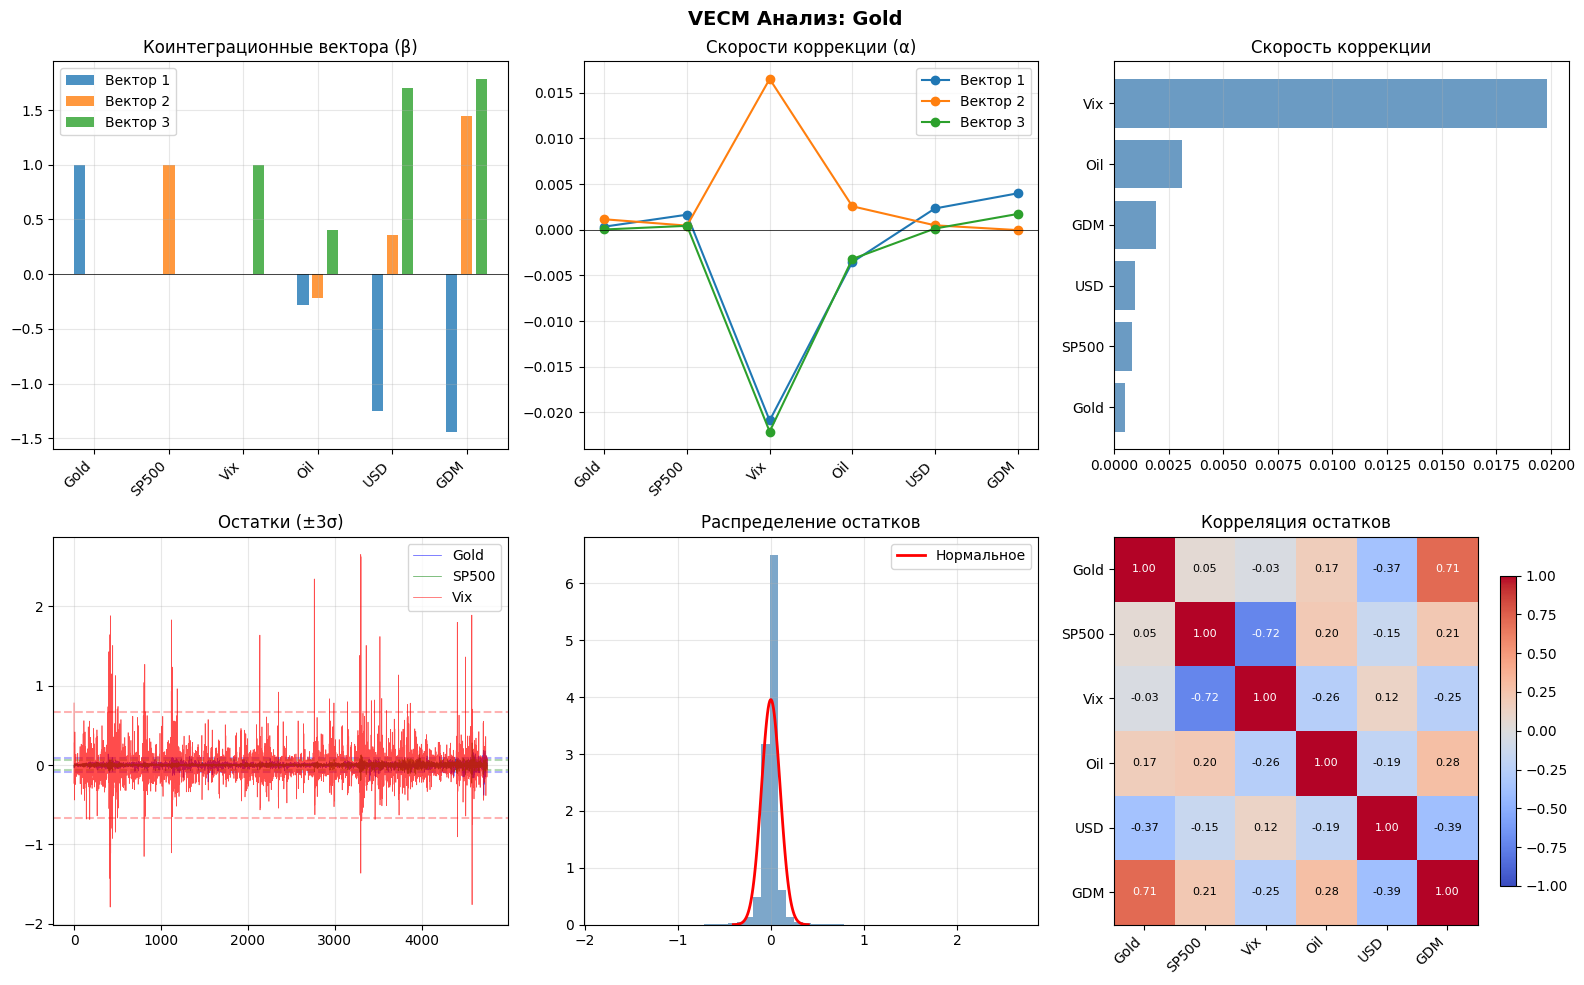

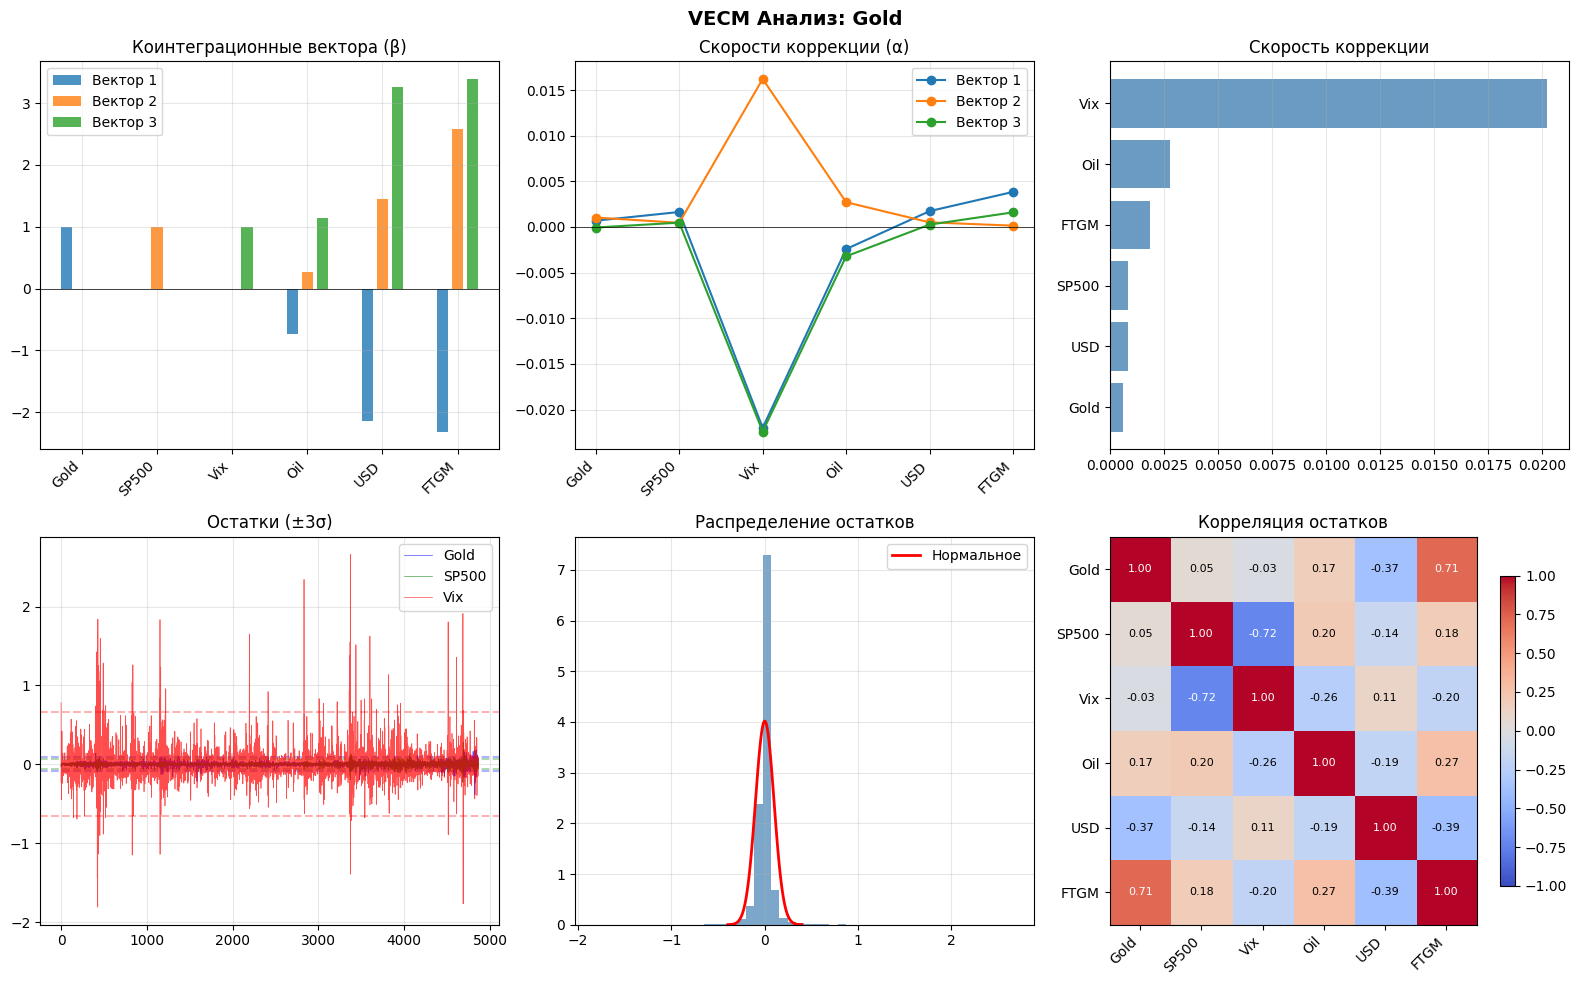

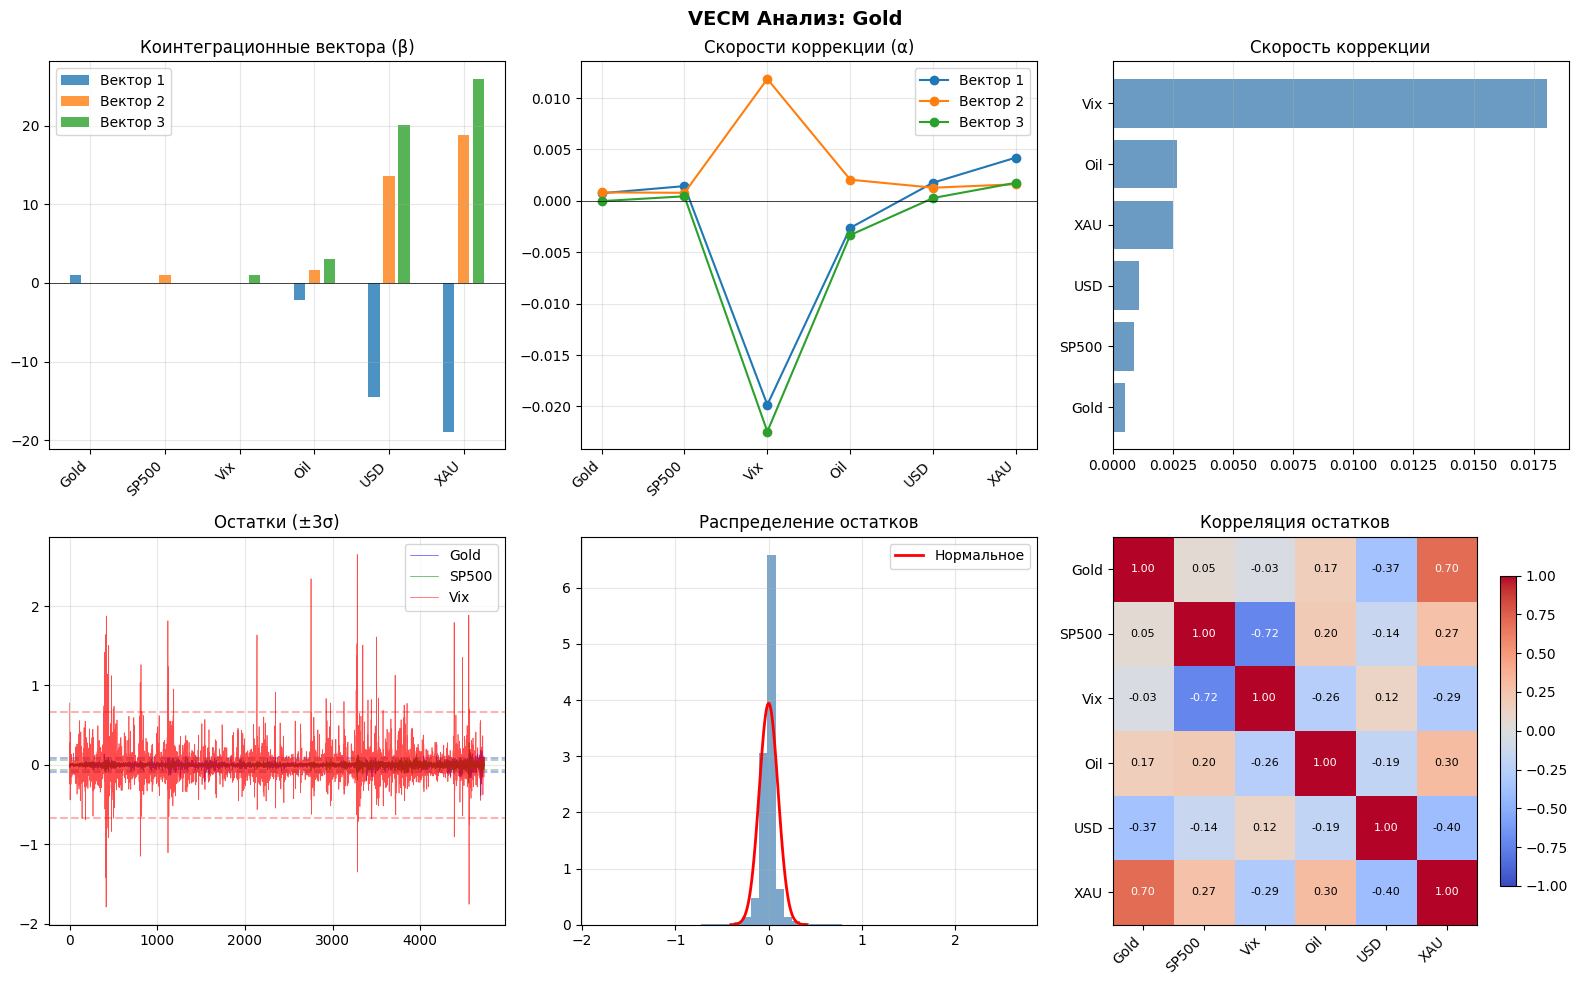

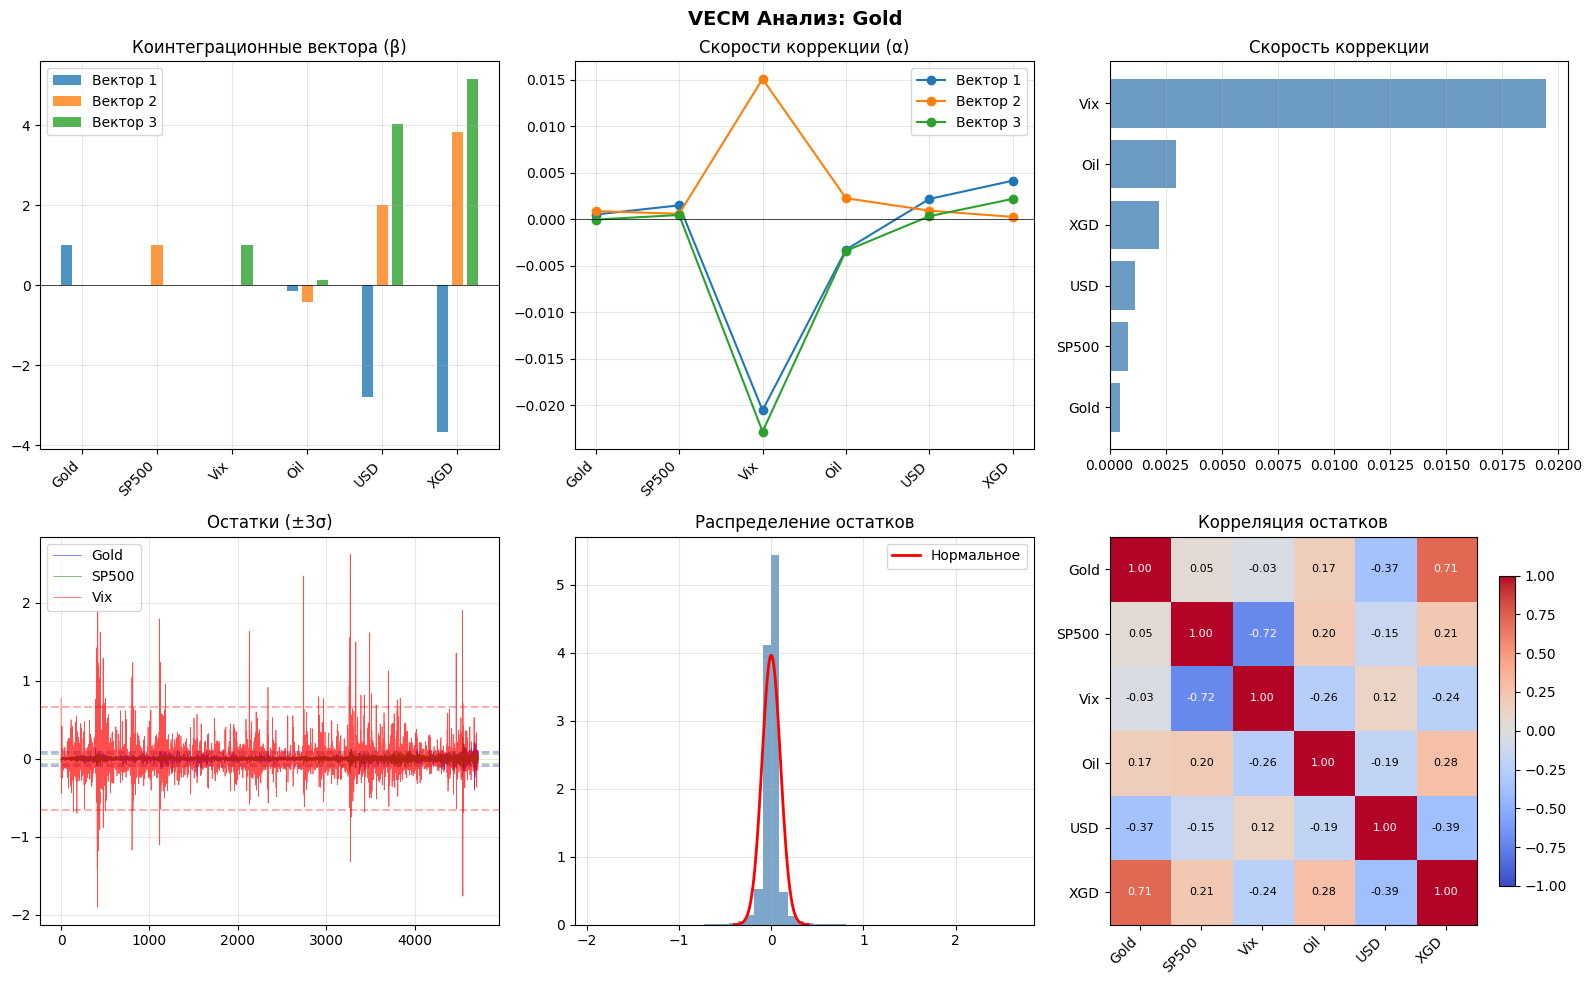

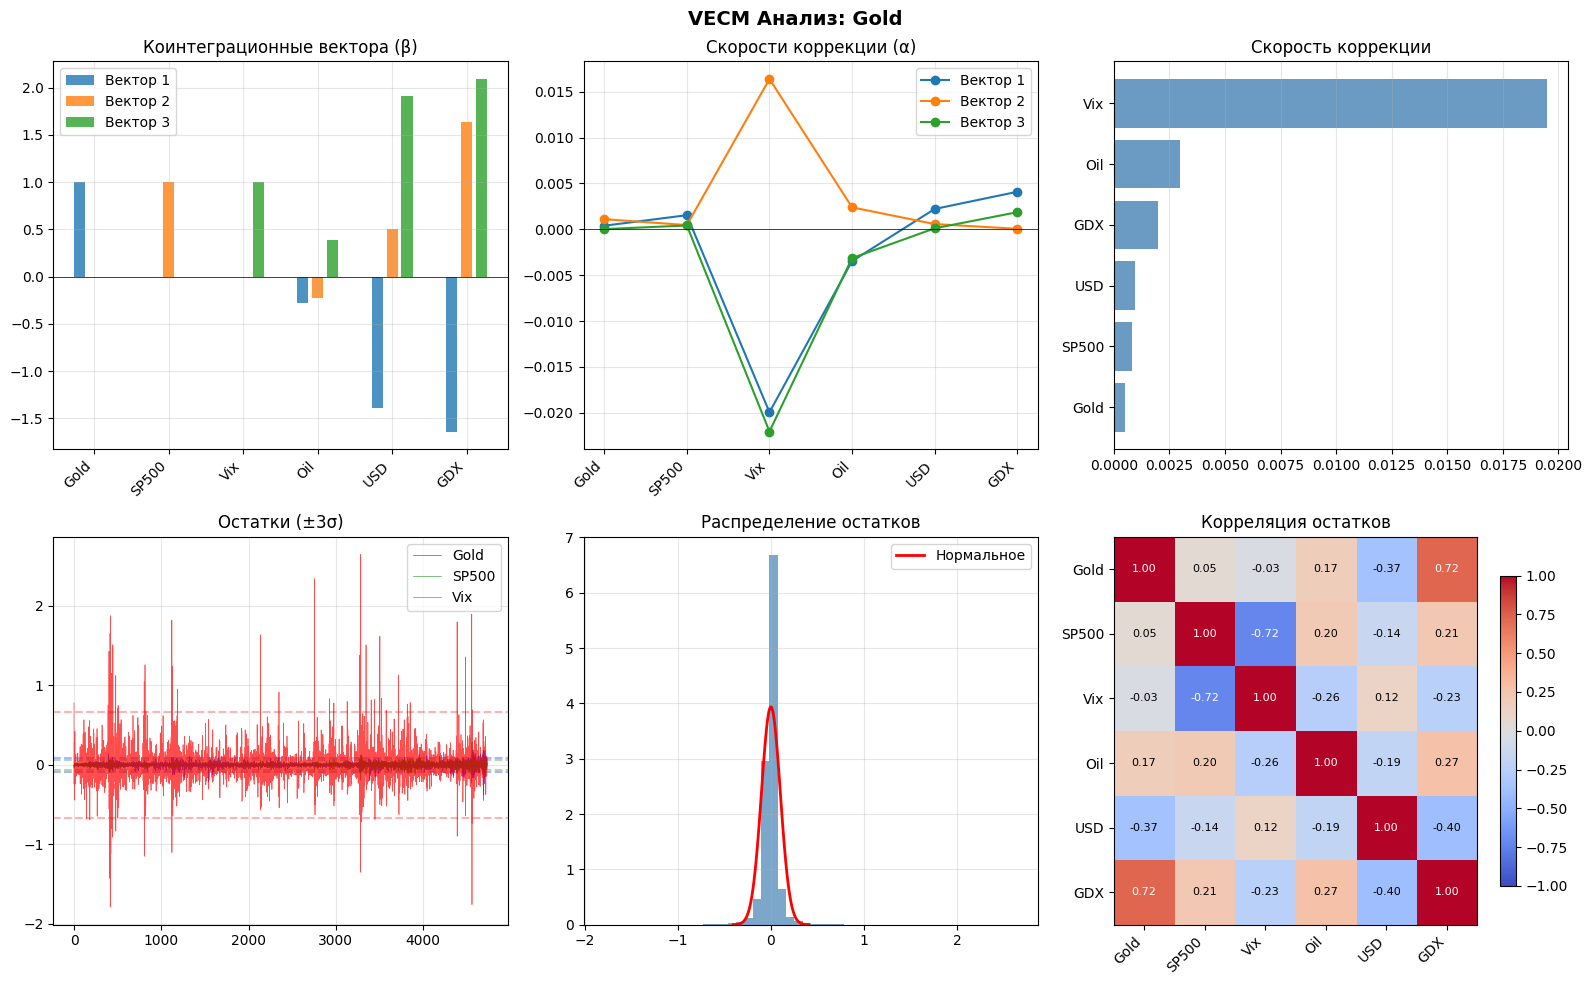

In [21]:
# ============================================
# ВИЗУАЛИЗАЦИЯ ДЛЯ КАЖДОГО ИНДЕКСА
# ============================================
print("="*80)
print("📊 ВИЗУАЛИЗАЦИЯ VECM МОДЕЛЕЙ")
print("="*80)

for result in all_results:
    idx = result.get('period_name', str(result['data_info']['columns'][0]))
    data_cols = result['data_info']['columns']
    data_subset = dataset[data_cols].dropna()
    
    if result['success'] and result['model'] is not None:
        visualize_vecm(result['model'], data_subset, idx)

---
## 7. Garch

In [22]:
# ============================================
# ДОПОЛНИТЕЛЬНЫЕ ИМПОРТЫ ДЛЯ VECM-GARCH
# ============================================
from arch import arch_model
import numpy as np
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank
import warnings
warnings.filterwarnings('ignore')

In [37]:
# ============================================
# 1. VECM ОЦЕНКА (с обработкой разных (k,r) и полной диагностикой)
# ============================================

from statsmodels.tsa.vector_ar.vecm import select_order, select_coint_rank
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import pandas as pd

idx_name = 'GDM'   # ← Изменяй здесь: GDM, GDX, HUI, FTGM, XAU и т.д.

print(f"{'='*85}")
print(f"VECM АНАЛИЗ: Gold + {idx_name}")
print(f"{'='*85}")

data = dataset[['Gold', idx_name]].dropna().copy()
print(f"Размер данных: {len(data)} наблюдений\n")

# 1. ADF
print("1. ADF тесты (уровни):")
for col in data.columns:
    pval = adfuller(data[col])[1]
    print(f"   {col:10} p-value = {pval:.5f} → {'Стационарно' if pval<0.05 else 'НЕстационарно'}")

# 2. Выбор лага
print("\n2. Выбор лага:")
lag_sel = select_order(data, maxlags=3, deterministic='ci')
print(f"   AIC  = {lag_sel.aic}")
print(f"   BIC  = {lag_sel.bic}")
optimal_lag = lag_sel.aic

# 3. Johansen
print(f"\n3. Johansen Trace тест (lag={optimal_lag}):")
rank_test = select_coint_rank(data, det_order=0, k_ar_diff=optimal_lag, method='trace', signif=0.05)
print(f"   Рекомендуемый ранг = {rank_test.rank}")

for i, stat in enumerate(rank_test.test_stats):
    crit = rank_test.crit_vals[i]
    print(f"     r ≤ {i}: stat={stat:.3f} | crit5%={crit:.3f} → {'Отвергаем' if stat > crit else 'Не отвергаем'}")

# 4. Оценка VECM с fallback
print(f"\n4. Оценка VECM:")
result_dict = {'success': False, 'model': None}

deterministic = 'ci'
for k, r in [(optimal_lag, rank_test.rank), 
             (min(optimal_lag, 4), max(rank_test.rank, 1)), 
             (3, 1), (2, 1)]:
    try:
        model = VECM(data, k_ar_diff=k, coint_rank=r, deterministic=deterministic)
        vecm_result = model.fit()
        result_dict['model'] = vecm_result
        result_dict['success'] = True
        print(f"   ✅ Успешно: k={k}, r={r}")
        break
    except Exception as e:
        print(f"   ⚠️  Не удалось (k={k}, r={r}): {str(e)[:70]}")

if not result_dict['success']:
    print("   ❌ VECM не удалось оценить")
    # Здесь можно остановить выполнение
    

VECM АНАЛИЗ: Gold + GDM
Размер данных: 4759 наблюдений

1. ADF тесты (уровни):
   Gold       p-value = 1.00000 → НЕстационарно
   GDM        p-value = 0.87376 → НЕстационарно

2. Выбор лага:
   AIC  = 2
   BIC  = 1

3. Johansen Trace тест (lag=2):
   Рекомендуемый ранг = 2
     r ≤ 0: stat=26.175 | crit5%=15.494 → Отвергаем
     r ≤ 1: stat=4.246 | crit5%=3.841 → Отвергаем

4. Оценка VECM:
   ✅ Успешно: k=2, r=2


In [38]:
# ============================================
# 2. КОИНТЕГРАЦИОННЫЕ ВЕКТОРА И СКОРОСТИ КОРРЕКЦИИ
# ============================================

if result_dict['success']:
    vecm_result = result_dict['model']
    
    print("\n" + "="*60)
    print("КОИНТЕГРАЦИОННЫЕ ВЕКТОРА (β)")
    print("="*60)
    
    if hasattr(vecm_result, 'beta') and vecm_result.beta is not None:
        beta_df = pd.DataFrame(
            vecm_result.beta,
            index=data.columns,
            columns=[f'VEC {i+1}' for i in range(vecm_result.beta.shape[1])]
        )
        print(beta_df.round(4))
        result_dict['beta'] = beta_df
    
    print("\n" + "="*60)
    print("СКОРОСТИ КОРРЕКЦИИ (α)")
    print("="*60)
    
    if hasattr(vecm_result, 'alpha') and vecm_result.alpha is not None:
        alpha_df = pd.DataFrame(
            vecm_result.alpha,
            index=data.columns,
            columns=[f'VEC {i+1}' for i in range(vecm_result.alpha.shape[1])]
        )
        print(alpha_df.round(6))
        result_dict['alpha'] = alpha_df
else:
    print("VECM не была успешно оценена")


КОИНТЕГРАЦИОННЫЕ ВЕКТОРА (β)
      VEC 1  VEC 2
Gold    1.0   -0.0
GDM    -0.0    1.0

СКОРОСТИ КОРРЕКЦИИ (α)
         VEC 1     VEC 2
Gold  0.001544  0.000552
GDM   0.001235 -0.001481


In [39]:
# ============================================
# 3. GARCH НА ОСТАТКАХ VECM
# ============================================

if result_dict['success']:
    vecm_resid = vecm_result.resid
    
    print("Оценка GARCH(1,1) на остатках VECM...")
    
    res_gold = arch_model(vecm_resid[:, 0], mean='Zero', vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
    res_mining = arch_model(vecm_resid[:, 1], mean='Zero', vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
    
    print(f"\nGold   GARCH AIC: {res_gold.aic:.2f}")
    print(f"{idx_name} GARCH AIC: {res_mining.aic:.2f}")
    
    # Сохраняем для следующих шагов
    print("\nСтандартизированные остатки получены.")
else:
    print("Невозможно построить GARCH — VECM не оценена")

Оценка GARCH(1,1) на остатках VECM...

Gold   GARCH AIC: 38796.59
GDM GARCH AIC: 41425.60

Стандартизированные остатки получены.


In [41]:
# ============================================
# 4. ПРОВЕРКА ОСТАТКОВ И DCC
# ============================================

if result_dict['success']:
    results_check = check_residuals_for_dcc(res_gold, res_mining)
    
    # DCC
    if results_check['gold']['pass'] and results_check['mining']['pass']:
        print("\n🎉 Остатки прошли проверку → строим DCC")
        
        Z = np.column_stack([res_gold.std_resid, res_mining.std_resid])
        Rt = dcc_correlation(Z, a=0.05, b=0.93)
        corr_series = Rt[:, 0, 1]
        
        plt.figure(figsize=(14, 7))
        plt.plot(data.index[-len(corr_series):], corr_series, color='darkblue', linewidth=1.8)
        plt.title(f'DCC Gold vs {idx_name} (VECM-GARCH)', fontsize=14)
        plt.ylabel('Динамическая корреляция')
        plt.xlabel('Дата')
        plt.ylim(-0.3, 1.1)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"\nСредняя DCC корреляция: {corr_series.mean():.4f}")
    else:
        print("\n⚠️  Проверка остатков не пройдена полностью.")
else:
    print("Невозможно продолжить — VECM не оценена")

NameError: name 'check_residuals_for_dcc' is not defined

In [42]:
# ============================================
# 3. ПРОВЕРКА ОСТАТКОВ ДЛЯ DCC (твоя функция)
# ============================================

def check_residuals_for_dcc(res_gold, res_mining, threshold=3):
    """Полная проверка остатков для DCC-GARCH"""
    print("=" * 60)
    print("ПРОВЕРКА ОСТАТКОВ ДЛЯ DCC-GARCH")
    print("=" * 60)
   
    results = {
        'gold': {'pass': True, 'issues': []},
        'mining': {'pass': True, 'issues': []}
    }
   
    # 1. Среднее ~0
    print("\n1. Проверка среднего значения:")
    for name, res in [('Gold', res_gold.std_resid), ('Mining', res_mining.std_resid)]:
        mean_val = res.mean()
        if abs(mean_val) > 0.1:
            print(f"  {name}: mean={mean_val:.4f} ❌")
            results[name.lower()]['issues'].append(f"Среднее {mean_val:.4f} ≠ 0")
        else:
            print(f"  {name}: mean={mean_val:.4f} ✅")
   
    # 2. Дисперсия ~1
    print("\n2. Проверка дисперсии:")
    for name, res in [('Gold', res_gold.std_resid), ('Mining', res_mining.std_resid)]:
        var_val = res.var()
        if abs(var_val - 1) > 0.2:
            print(f"  {name}: var={var_val:.4f} ❌")
            results[name.lower()]['issues'].append(f"Дисперсия {var_val:.4f} ≠ 1")
        else:
            print(f"  {name}: var={var_val:.4f} ✅")
   
    # 3. Выбросы
    print("\n3. Проверка выбросов (>3σ):")
    for name, res in [('Gold', res_gold.std_resid), ('Mining', res_mining.std_resid)]:
        outliers = np.abs(res) > threshold
        percent = outliers.sum() / len(res) * 100
        if percent > 1.0:
            print(f"  {name}: {outliers.sum()} выбросов ({percent:.2f}%) ⚠️")
            if percent > 5:
                results[name.lower()]['issues'].append(f"Много выбросов: {percent:.1f}%")
        else:
            print(f"  {name}: {outliers.sum()} выбросов ({percent:.2f}%) ✅")
   
    # 4. ARCH эффекты
    print("\n4. Проверка остаточных ARCH эффектов:")
    from statsmodels.stats.diagnostic import het_arch
    for name, res, lags in [('Gold', res_gold.std_resid, 8), ('Mining', res_mining.std_resid, 6)]:
        _, p_value, _, _ = het_arch(res, nlags=lags)
        if p_value < 0.05:
            print(f"  {name}: p={p_value:.4f} ❌ Есть ARCH")
            results[name.lower()]['issues'].append(f"ARCH эффекты (p={p_value:.4f})")
        else:
            print(f"  {name}: p={p_value:.4f} ✅ Нет ARCH")
   
    # Итог
    print("\n" + "=" * 60)
    print("ИТОГОВАЯ ОЦЕНКА:")
    print("=" * 60)
   
    all_pass = True
    for name in ['gold', 'mining']:
        if results[name]['issues']:
            print(f"\n❌ {name.capitalize()}: Есть проблемы")
            print(f"   → {', '.join(results[name]['issues'])}")
            all_pass = False
        else:
            print(f"\n✅ {name.capitalize()}: Готово для DCC")
   
    if all_pass:
        print("\n🎉 ОСТАТКИ ПРОШЛИ ПРОВЕРКУ — можно строить DCC!")
    else:
        print("\n⚠️ Есть замечания. Рекомендуется доработать GARCH модель.")
   
    return results


# Запуск проверки
check_results = check_residuals_for_dcc(res_gold, res_mining)

ПРОВЕРКА ОСТАТКОВ ДЛЯ DCC-GARCH

1. Проверка среднего значения:
  Gold: mean=0.0064 ✅
  Mining: mean=-0.0118 ✅

2. Проверка дисперсии:
  Gold: var=0.9999 ✅
  Mining: var=1.0072 ✅

3. Проверка выбросов (>3σ):
  Gold: 48 выбросов (1.01%) ⚠️
  Mining: 41 выбросов (0.86%) ✅

4. Проверка остаточных ARCH эффектов:
  Gold: p=0.6658 ✅ Нет ARCH
  Mining: p=0.3354 ✅ Нет ARCH

ИТОГОВАЯ ОЦЕНКА:

✅ Gold: Готово для DCC

✅ Mining: Готово для DCC

🎉 ОСТАТКИ ПРОШЛИ ПРОВЕРКУ — можно строить DCC!



Строим DCC корреляцию...


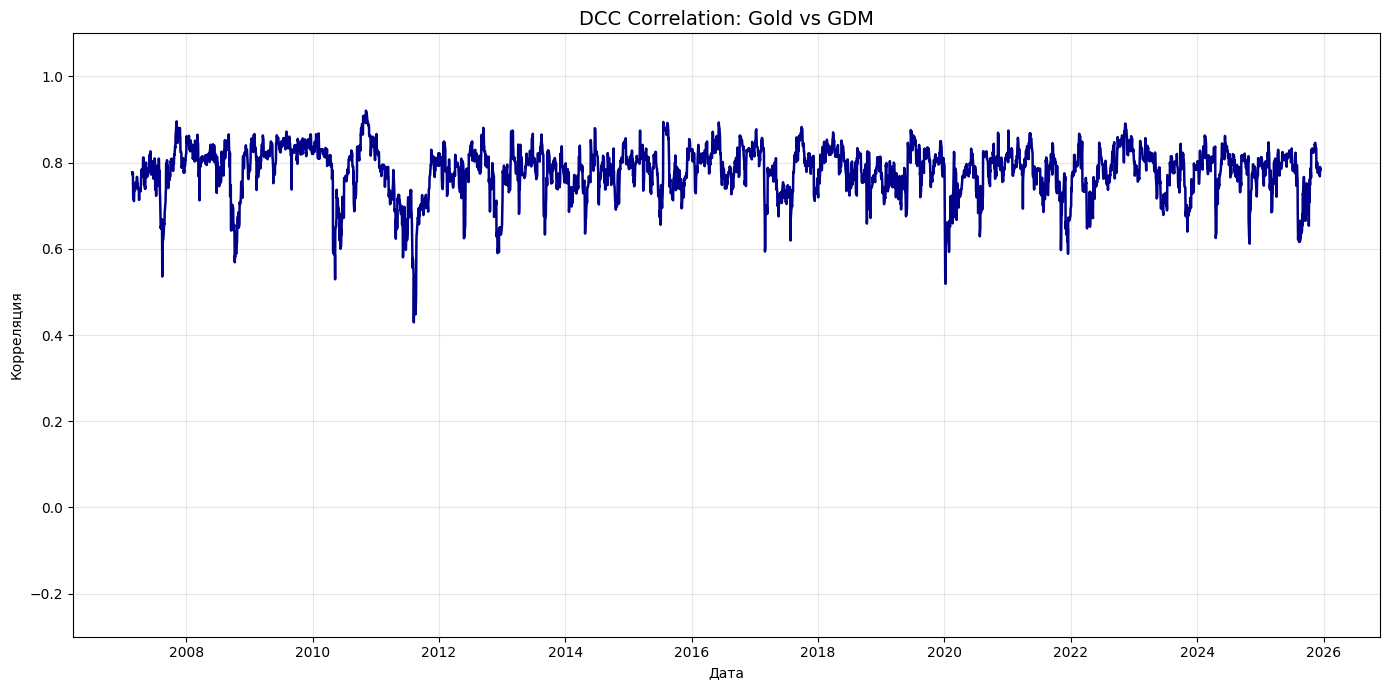


Средняя динамическая корреляция: 0.7804


In [44]:
# ============================================
# 4. DCC КОРРЕЛЯЦИЯ (после проверки остатков)
# ============================================

if check_results['gold']['pass'] and check_results['mining']['pass']:
    print("\nСтроим DCC корреляцию...")
    
    Z = np.column_stack([res_gold.std_resid, res_mining.std_resid])
    Rt = dcc_correlation(Z, a=0.05, b=0.93)
    corr_series = Rt[:, 0, 1]
    
    plt.figure(figsize=(14, 7))
    plt.plot(data_pair.index[-len(corr_series):], corr_series, linewidth=1.8, color='darkblue')
    plt.title(f'DCC Correlation: Gold vs {idx_name}', fontsize=14)
    plt.ylabel('Корреляция')
    plt.xlabel('Дата')
    plt.ylim(-0.3, 1.1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nСредняя динамическая корреляция: {corr_series.mean():.4f}")
else:
    print("\n⚠️ Проверка остатков не пройдена. DCC строить не рекомендуется.")

In [43]:
# ============================================
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ DCC (standalone)
# ============================================

def dcc_correlation(Z, a=0.05, b=0.93):
    """
    Простая реализация DCC корреляции
    Z: (T x 2) массив стандартизированных остатков
    """
    T, N = Z.shape
    Q = np.zeros((T, N, N))
    Rt = np.zeros((T, N, N))
    
    # Инициализация
    Q[0] = np.corrcoef(Z.T)
    Rt[0] = Q[0].copy()
    
    for t in range(1, T):
        Q[t] = (1 - a - b) * np.corrcoef(Z.T) + \
               a * np.outer(Z[t-1], Z[t-1]) + \
               b * Q[t-1]
        
        # Нормализация в корреляционную матрицу
        d = np.sqrt(np.diag(Q[t]))
        Rt[t] = np.diag(1/d) @ Q[t] @ np.diag(1/d)
    
    return Rt

---
## 7. Прогнозирование

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def compute_forecast_metrics(y_true, y_pred, name=None):
    """Метрики прогноза"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    if len(y_true) == 0:
        return None
    
    ret = {}
    ret['MAE'] = mean_absolute_error(y_true, y_pred)
    ret['MAPE'] = mean_absolute_percentage_error(y_true, y_pred)
    ret['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
    ret['R2'] = r2_score(y_true, y_pred)
    ret['Corr'] = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 2 else np.nan
    ret['ME'] = np.mean(y_pred - y_true)
    
    # Direction accuracy
    if len(y_true) > 2:
        d_true = np.sign(np.diff(y_true))
        d_pred = np.sign(np.diff(y_pred))
        ret['Dir_Acc'] = np.mean(d_true == d_pred) * 100
    else:
        ret['Dir_Acc'] = np.nan
    
    return ret

def vecm_forecast(data, k_ar_diff=4, coint_rank=3, forecast_steps=12):
    print(f"\n{'='*60}")
    print(f"📊 VECM FORECAST: {forecast_steps} шагов")
    print(f"{'='*60}")
    
    data_c = data.dropna()
    if len(data_c) < 50 + forecast_steps:
        print("Недостаточно данных для такого горизонта прогноза")
        return None, None
    
    # Разделение
    tr_sz = int(len(data_c) * 0.85)
    # Убедимся, что в тесте остаётся хотя бы forecast_steps наблюдений
    if len(data_c) - tr_sz < forecast_steps:
        # Если остаётся меньше, сдвигаем границу
        tr_sz = len(data_c) - forecast_steps
    train = data_c.iloc[:tr_sz]
    test = data_c.iloc[tr_sz:tr_sz+forecast_steps]  # берём ровно forecast_steps для сравнения
    
    print(f"Train: {len(train)}, Test: {len(test)}")
    
    # Пробуем разные конфиги
    model = None
    for k, r in [(k_ar_diff, coint_rank), (2, 1), (1, 1)]:
        try:
            m = VECM(endog=train, k_ar_diff=k, coint_rank=r, deterministic='ci').fit()
            model = m
            print(f"✅ Модель: k={k}, r={r}")
            break
        except Exception as e:
            print(f"  ⚠️ k={k}, r={r}: {str(e)[:50]}")
    
    if model is None:
        print("❌ VECM не построена")
        return None, None
    
    # Out-of-sample прогноз
    fc = model.predict(steps=forecast_steps)
    # Создаём DataFrame с прогнозами, используя индекс тестовой выборки
    fdf = pd.DataFrame(fc, columns=data.columns, index=test.index)
    
    metrics = {}
    for c in data.columns:
        m = compute_forecast_metrics(test[c].values, fdf[c].values, c)
        if m:
            metrics[c] = m
    
    print("\n📊 Метрики прогноза:")
    print(f"{'Variable':10} {'MAE':8}  {'RMSE':8}  {'MAPE':8}  {'R2':8}  {'DirAcc':8}")
    print("-"*60)
    for c, m in metrics.items():
        print(f"{c:10} {m['MAE']:8.4f} {m['RMSE']:8.4f} {m['MAPE']:8.4f} {m['R2']:8.4f} {m['Dir_Acc']:8.1f}")
    
    return model, metrics

In [46]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings('ignore', category=ValueWarning)

# ============================================
# ЗАПУСК ПРОГНОЗА ДЛЯ ВЫБРАННЫХ ПАР
# ============================================
# Пример: прогноз для Gold + GDM
target_pairs = [
    ['Gold', 'GDX'],
    ['Gold', 'GDM'],
    ['Gold', 'HUI'],
]

for cols in target_pairs:
    valid_cols = [c for c in cols if c in dataset.columns]
    if len(valid_cols) >= 2:
        model, metrics = vecm_forecast(dataset[valid_cols], forecast_steps=5)
        model, metrics = vecm_forecast(dataset[valid_cols], forecast_steps=10)
        model, metrics = vecm_forecast(dataset[valid_cols], forecast_steps=30)
        print()


📊 VECM FORECAST: 5 шагов
Train: 4029, Test: 5
✅ Модель: k=4, r=3

📊 Метрики прогноза:
Variable   MAE       RMSE      MAPE      R2        DirAcc  
------------------------------------------------------------
Gold         6.3722   7.7541   0.0035  -0.1440    100.0
GDX          0.7174   0.8802   0.0260  -1.7525    100.0

📊 VECM FORECAST: 10 шагов
Train: 4029, Test: 10
✅ Модель: k=4, r=3

📊 Метрики прогноза:
Variable   MAE       RMSE      MAPE      R2        DirAcc  
------------------------------------------------------------
Gold         8.5290  11.0851   0.0047  -0.3729     66.7
GDX          0.8599   1.0094   0.0313  -2.4889     55.6

📊 VECM FORECAST: 30 шагов
Train: 4029, Test: 30
✅ Модель: k=4, r=3

📊 Метрики прогноза:
Variable   MAE       RMSE      MAPE      R2        DirAcc  
------------------------------------------------------------
Gold        65.1757  89.0647   0.0334  -0.8450     48.3
GDX          1.6851   2.0872   0.0563  -0.3401     44.8


📊 VECM FORECAST: 5 шагов
Train: 40

In [47]:
def vecm_forecast_full(data, forecast_steps=5, train_ratio=0.85, max_lags=4):
    """
    VECM прогноз с макрофакторами.
    Использует скользящее окно (рекурсивное обучение) для каждого шага прогноза,
    что более стабильно, чем статический прогноз на 30 шагов.
    """
    data_c = data.dropna()
    n = len(data_c)
    tr_sz = int(n * train_ratio)
    
    # Подбор лагов и ранга на первых train_ratio данных
    # train_init = data_c.iloc[:tr_sz]
    # try:
    #     lag_order = select_order(train_init, maxlags=max_lags)
    #     optimal_lag = lag_order.aic
    # except:
    #     optimal_lag = 4
    # try:
    #     jres = coint_johansen(train_init, det_order=0, k_ar_diff=optimal_lag)
    #     rank = 0
    #     for i in range(len(jres.lr1)):
    #         if jres.lr1[i] > jres.cvt[i, 1]:
    #             rank = i + 1
    #     # ограничим ранг максимально возможным (не более 3, чтобы избежать проблем)
    #     rank = min(rank, len(data.columns)-1, 3)
    # except:
    #     rank = 2
    
    # print(f"Подобранные параметры: лаг={optimal_lag}, ранг={rank}")
    
    # Рекурсивное прогнозирование
    predictions = []
    actuals = []
    # Будем двигать окно: на каждом шаге обучаем модель на предыдущих tr_sz наблюдениях,
    # прогнозируем на forecast_steps вперёд, но для оценки берём только первый шаг?
    # Для чистоты сделаем прогноз на 1 шаг вперёд, сдвигая окно.
    # (Можно и на несколько, но тогда ошибка накапливается)
    for i in range(tr_sz, n - forecast_steps + 1):
        train = data_c.iloc[i-tr_sz:i]
        test = data_c.iloc[i:i+forecast_steps]
        # Оцениваем VECM
        try:
            model = VECM(train, k_ar_diff=4, coint_rank=3, deterministic='ci').fit()
            fc = model.predict(steps=forecast_steps)
            # Сохраняем последний прогноз (на весь горизонт) и фактические значения
            predictions.append(fc)
            actuals.append(test.values)
        except:
            continue
    # Преобразуем в массивы для метрик
    if len(predictions) == 0:
        return None, None
    pred_array = np.array(predictions)  # (n_pred, forecast_steps, n_vars)
    actual_array = np.array(actuals)
    
    # Рассчитаем метрики для каждого шага внутри горизонта
    metrics_per_horizon = {}
    for step in range(forecast_steps):
        step_pred = pred_array[:, step, :]
        step_actual = actual_array[:, step, :]
        step_metrics = {}
        for j, col in enumerate(data.columns):
            m = compute_forecast_metrics(step_actual[:, j], step_pred[:, j])
            if m:
                step_metrics[col] = m
        metrics_per_horizon[step+1] = step_metrics
    
    # Усредним по всем шагам для общего показателя
    avg_metrics = {}
    for col in data.columns:
        mae_vals = [metrics_per_horizon[step][col]['MAE'] for step in range(1, forecast_steps+1) if col in metrics_per_horizon[step]]
        if mae_vals:
            avg_metrics[col] = {
                'MAE': np.mean(mae_vals),
                'RMSE': np.mean([metrics_per_horizon[step][col]['RMSE'] for step in range(1, forecast_steps+1)]),
                'MAPE': np.mean([metrics_per_horizon[step][col]['MAPE'] for step in range(1, forecast_steps+1)]),
                'DirAcc': np.mean([metrics_per_horizon[step][col]['Dir_Acc'] for step in range(1, forecast_steps+1)])
            }
    return avg_metrics, metrics_per_horizon

# Пример использования
full_vars = ['Gold', 'GDM', 'SP500', 'USD', 'Oil', 'Vix']
data_full = dataset[full_vars].dropna()
metrics, by_step = vecm_forecast_full(data_full, forecast_steps=5, train_ratio=0.85)
print(metrics)

{'Gold': {'MAE': 34.85423203843207, 'RMSE': 49.49959589943755, 'MAPE': 0.012770502778963216, 'DirAcc': 49.91525423728814}, 'GDM': {'MAE': 31.561549939253098, 'RMSE': 44.021137708556786, 'MAPE': 0.026993987203295537, 'DirAcc': 51.24293785310734}, 'SP500': {'MAE': 58.62056719908804, 'RMSE': 82.26939470374417, 'MAPE': 0.011100351295342111, 'DirAcc': 50.50847457627118}, 'USD': {'MAE': 0.549298026048947, 'RMSE': 0.7150691447919939, 'MAPE': 0.005346680305006718, 'DirAcc': 47.93785310734464}, 'Oil': {'MAE': 1.8021164408087564, 'RMSE': 2.3731282873206743, 'MAPE': 0.02372824943178097, 'DirAcc': 48.53107344632768}, 'Vix': {'MAE': 1.643537062304712, 'RMSE': 2.7627922137678764, 'MAPE': 0.0883545966752574, 'DirAcc': 49.40677966101695}}


In [ ]:
# ============================================
# 10. ПРОГНОЗИРОВАНИЕ VECM-GARCH (исправленная версия)
# ============================================

def vecm_garch_forecast(pair_data, index_name, forecast_steps=10, train_ratio=0.85):
    """
    Комбинированный прогноз VECM + GARCH + DCC
    """
    print(f"\n{'='*80}")
    print(f"📈 ПРОГНОЗ VECM-GARCH: Gold + {index_name} ({forecast_steps} шагов)")
    print(f"{'='*80}")
    
    data = pair_data.dropna().copy()
    n = len(data)
    train_size = int(n * train_ratio)
    
    train = data.iloc[:train_size]
    test  = data.iloc[train_size:train_size + forecast_steps]
    
    if len(test) == 0:
        print("❌ Недостаточно данных для теста")
        return None
    
    # 1. Автоподбор параметров
    lag_order = select_order(train[['Gold', index_name]], maxlags=6, deterministic='ci').aic
    rank_test = select_coint_rank(train[['Gold', index_name]], 
                                  det_order=0, k_ar_diff=lag_order, 
                                  method='trace', signif=0.05)
    coint_rank = rank_test.rank
    
    print(f"Параметры → lag={lag_order}, rank={coint_rank}")
    
    # 2. VECM
    vecm_model = VECM(train[['Gold', index_name]], 
                      k_ar_diff=lag_order, 
                      coint_rank=coint_rank, 
                      deterministic='ci').fit()
    
    # Прогноз среднего
    vecm_fc = vecm_model.predict(steps=forecast_steps)
    vecm_forecast_df = pd.DataFrame(vecm_fc, 
                                    columns=['Gold_fc', f'{index_name}_fc'], 
                                    index=test.index)
    
    # 3. GARCH на остатках
    resid = vecm_model.resid
    garch_gold = arch_model(resid[:, 0], mean='Zero', vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
    garch_idx  = arch_model(resid[:, 1], mean='Zero', vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
    
    # Прогноз волатильности
    gold_vol_fc = np.sqrt(garch_gold.forecast(horizon=forecast_steps).variance.iloc[-1].values)
    idx_vol_fc  = np.sqrt(garch_idx.forecast(horizon=forecast_steps).variance.iloc[-1].values)
    
    # 4. DCC
    z_gold = garch_gold.std_resid
    z_idx  = garch_idx.std_resid
    Z = np.column_stack([z_gold, z_idx])
    
    Rt = dcc_correlation(Z, a=0.05, b=0.93)
    last_corr = Rt[-1, 0, 1]
    
    print(f"Последняя DCC корреляция: {last_corr:.4f}")
    
    # 5. Метрики
    print("\n📊 Метрики прогноза уровней:")
    print(f"{'Variable':10} {'MAE':8} {'RMSE':8} {'MAPE (%)':9}")
    print("-" * 45)
    
    metrics = {}
    for col, fc_col in [('Gold', 'Gold_fc'), (index_name, f'{index_name}_fc')]:
        mae = mean_absolute_error(test[col], vecm_forecast_df[fc_col])
        rmse = np.sqrt(mean_squared_error(test[col], vecm_forecast_df[fc_col]))
        mape = np.mean(np.abs((test[col] - vecm_forecast_df[fc_col]) / test[col])) * 100
        
        metrics[col] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
        print(f"{col:10} {mae:8.3f} {rmse:8.3f} {mape:8.2f}")
    
    # 6. Визуализация
    plt.figure(figsize=(15, 10))
    
    plt.subplot(3, 1, 1)
    plt.plot(train.index[-120:], train['Gold'][-120:], label='Gold Train', color='gold')
    plt.plot(test.index, test['Gold'], label='Gold Actual', color='darkgoldenrod', linewidth=2)
    plt.plot(test.index, vecm_forecast_df['Gold_fc'], label='Gold Forecast', 
             color='red', linestyle='--', linewidth=2.5)
    plt.title(f'Прогноз цены Gold — {index_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 1, 2)
    plt.plot(train.index[-120:], train[index_name][-120:], label=f'{index_name} Train', color='blue')
    plt.plot(test.index, test[index_name], label=f'{index_name} Actual', color='navy', linewidth=2)
    plt.plot(test.index, vecm_forecast_df[f'{index_name}_fc'], label=f'{index_name} Forecast', 
             color='red', linestyle='--', linewidth=2.5)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 1, 3)
    plt.plot(data.index[-250:], Rt[-250:, 0, 1], label='DCC Correlation (history)', color='purple')
    plt.axhline(last_corr, color='red', linestyle='--', linewidth=2, 
                label=f'Forecast Corr = {last_corr:.3f}')
    plt.title('Динамическая корреляция Gold–Index')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'vecm_forecast': vecm_forecast_df,
        'metrics': metrics,
        'last_dcc': last_corr,
        'gold_vol_fc': gold_vol_fc,
        'idx_vol_fc': idx_vol_fc
    }


# ============================================
# ЗАПУСК ПРОГНОЗОВ
# ============================================

forecast_results = {}

for idx_name in ['GDM', 'GDX', 'HUI', 'FTGM']:
    if idx_name in dataset.columns:
        print(f"\n→ Запуск прогноза для {idx_name}")
        pair_df = dataset[['Gold', idx_name]]
        res = vecm_garch_forecast(pair_df, idx_name, forecast_steps=10)
        if res:
            forecast_results[idx_name] = res

---
## 8. Выводы

In [27]:
print("="*80)
print("📊 ИТОГОВЫЕ ВЫВОДЫ")
print("="*80)

print(f"\n📌 ДАТАСЕТ: {SELECTED_DATASET}")
print(f"   Период: {dataset.index.min().year} - {dataset.index.max().year}")
print(f"   Наблюдений: {len(dataset)}")
print(f"   Индексов: {len([c for c in indices_list if c in dataset.columns])}")

print("\n📌 УСПЕШНЫЕ VECM МОДЕЛИ:")
success_count = sum(1 for r in all_results if r['success'])
print(f"   {success_count} из {len(all_results)}")

print("\n📌 КОИНТЕГРАЦИЯ:")
coint_count = sum(1 for r in all_results if r.get('has_cointegration', False))
print(f"   Коинтеграция обнаружена в {coint_count} из {success_count} моделей")

print("\n📌 РЕКОМЕНДАЦИИ:")
print("   - Используйте VECM для пар с коинтеграцией")
print("   - Для остальных пар используйте VAR в разностях")
print("   - Увеличьте лаг для лучшего качества прогноза")

📊 ИТОГОВЫЕ ВЫВОДЫ

📌 ДАТАСЕТ: dataset_2007
   Период: 2007 - 2026
   Наблюдений: 5219
   Индексов: 5

📌 УСПЕШНЫЕ VECM МОДЕЛИ:
   5 из 5

📌 КОИНТЕГРАЦИЯ:
   Коинтеграция обнаружена в 5 из 5 моделей

📌 РЕКОМЕНДАЦИИ:
   - Используйте VECM для пар с коинтеграцией
   - Для остальных пар используйте VAR в разностях
   - Увеличьте лаг для лучшего качества прогноза
